# Imports, versões e reprodutibilidade

In [35]:
!pip install optuna -q
!pip install tensorflow -q

In [36]:
!python --version
!pip show tensorflow

Python 3.12.13
Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tf_keras, ydf_tf


In [37]:
import os
import pathlib
import random
import shutil
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import optuna

import kagglehub

# Exibe as versões das bibliotecas para garantir compatibilidade
print(f"Versões usadas:\n"
      f"TensorFlow: {tf.__version__}\n"
      f"Keras: {keras.__version__}\n"
      f"NumPy: {np.__version__}\n"
      f"Pandas: {pd.__version__}\n"
      f"Matplotlib: {matplotlib.__version__}\n")
print(f"Versão do Optuna: {optuna.__version__}")
# --- Configuração de reprodutibilidade ---
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Versões usadas:
TensorFlow: 2.20.0
Keras: 3.13.2
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0

Versão do Optuna: 4.9.0


# Download do dataset

In [38]:
data_dir = kagglehub.dataset_download("drgfreeman/rockpaperscissors")

data_dir = pathlib.Path(data_dir)

print("Caminho final do dataset:")
print(data_dir)

class_names = sorted([item.name for item in data_dir.iterdir() if item.is_dir()])
class_names.remove('rps-cv-images')

print("\nClasses encontradas:")
print(class_names)

100%|██████████| 306M/306M [00:17<00:00, 18.3MB/s]

Extracting files...


Caminho final do dataset:
/root/.cache/kagglehub/datasets/drgfreeman/rockpaperscissors/versions/2

Classes encontradas:
['paper', 'rock', 'scissors']


## Construção do dataframe de imagens

In [39]:
# --- Construção de um dataframe com caminhos das imagens e classes ---

image_paths = []
labels = []

for class_name in class_names:
    class_dir = data_dir / class_name

    for image_path in class_dir.glob("*"):
        image_paths.append(str(image_path))
        labels.append(class_name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

# Cria um mapeamento entre o nome da classe e um código numérico
label_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}
id_to_label = {idx: class_name for class_name, idx in label_to_id.items()}

df["label_id"] = df["label"].map(label_to_id).astype("int32")

print("Total de imagens:", len(df))
print("\n Mapeamento das classes:")
print(label_to_id)

print("\n Amostra do dataframe:")
display(df.head())

print("\n Distribuição das classes:")
display(df["label"].value_counts())

Total de imagens: 2188

 Mapeamento das classes:
{'paper': 0, 'rock': 1, 'scissors': 2}

 Amostra do dataframe:


,image_path,label,label_id
0,/root/.cache/kagglehub/datasets/drgfreeman/roc...,paper,0
1,/root/.cache/kagglehub/datasets/drgfreeman/roc...,paper,0
2,/root/.cache/kagglehub/datasets/drgfreeman/roc...,paper,0
3,/root/.cache/kagglehub/datasets/drgfreeman/roc...,paper,0
4,/root/.cache/kagglehub/datasets/drgfreeman/roc...,paper,0



 Distribuição das classes:


,count
label,
scissors,750
rock,726
paper,712


## Visualização de amostras

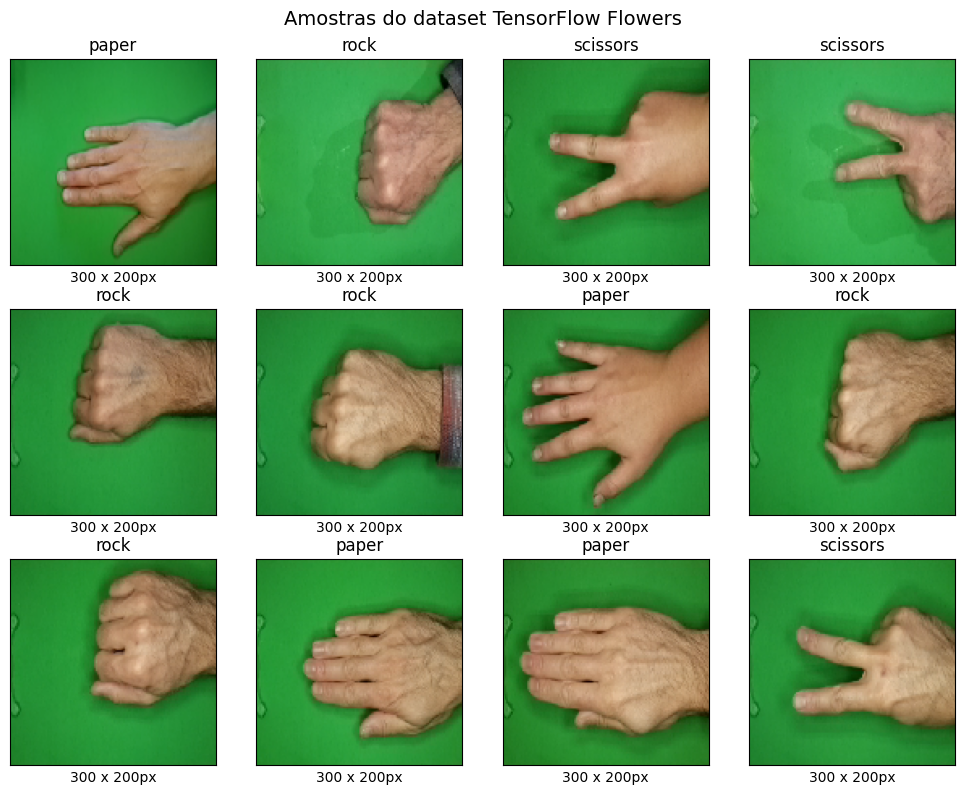

In [40]:
# --- Visualização de algumas imagens do dataset ---

plt.figure(figsize=(10, 8))

sample_df = df.sample(12, random_state=SEED).reset_index(drop=True)

for i, row in sample_df.iterrows():
    # Carrega a imagem no tamanho original apenas para verificar suas dimensões
    img_original = tf.keras.utils.load_img(row["image_path"])
    largura, altura = img_original.size

    # Carrega a imagem redimensionada apenas para visualização padronizada na grade
    img = tf.keras.utils.load_img(row["image_path"], target_size=(128, 128))

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.xlabel(f"{largura} x {altura}px")
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Amostras do dataset TensorFlow Flowers", fontsize=14)
plt.tight_layout()
plt.show()

## Divisão do dataset

In [41]:
# --- Divisão holdout: treino, validação e teste ---
# O conjunto de teste será separado desde o início e usado apenas na avaliação final.

# Primeiro, separamos 15% dos dados para teste.
df_temp, df_teste = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label_id"],
    random_state=SEED
)

# Depois, separamos parte do restante para validação.
# Como o df_temp contém 85% dos dados, usar test_size=0.1765 gera aproximadamente 15% do total original para validação.
df_treino, df_validacao = train_test_split(
    df_temp,
    test_size=0.1765,
    stratify=df_temp["label_id"],
    random_state=SEED
)

print("Quantidade de imagens em cada conjunto:")
print(f"Treino: {len(df_treino)} imagens")
print(f"Validação: {len(df_validacao)} imagens")
print(f"Teste: {len(df_teste)} imagens")

print("\n Percentuais aproximados:")
print(f"Treino: {len(df_treino) / len(df) * 100:.1f}%")
print(f"Validação: {len(df_validacao) / len(df) * 100:.1f}%")
print(f"Teste: {len(df_teste) / len(df) * 100:.1f}%")
# --- Conferência da distribuição das classes em cada conjunto ---

dist_treino = df_treino["label"].value_counts(normalize=True).sort_index()
dist_validacao = df_validacao["label"].value_counts(normalize=True).sort_index()
dist_teste = df_teste["label"].value_counts(normalize=True).sort_index()

df_distribuicao = pd.DataFrame({
    "Treino (%)": dist_treino * 100,
    "Validação (%)": dist_validacao * 100,
    "Teste (%)": dist_teste * 100
})

display(df_distribuicao.round(2))

Quantidade de imagens em cada conjunto:
Treino: 1530 imagens
Validação: 329 imagens
Teste: 329 imagens

 Percentuais aproximados:
Treino: 69.9%
Validação: 15.0%
Teste: 15.0%


,Treino (%),Validação (%),Teste (%)
label,,,
paper,32.55,32.52,32.52
rock,33.20,33.13,33.13
scissors,34.25,34.35,34.35


# Criar dataset

In [42]:
# --- Parâmetros principais ---

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

num_classes = len(class_names)

print(f" Tamanho das imagens: {IMG_SIZE}")
print(f" Batch size: {BATCH_SIZE}")
print(f" Número de classes: {num_classes}")

# --- Função para carregar e preparar cada imagem ---

def carregar_imagem(image_path, label):
    # Lê o arquivo da imagem
    img = tf.io.read_file(image_path)

    # Decodifica a imagem em 3 canais (RGB)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)

    # Redimensiona para o tamanho definido
    img = tf.image.resize(img, IMG_SIZE)

    # Normaliza os pixels para o intervalo [0, 1]
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

    # --- Função para criar um tf.data.Dataset a partir de um dataframe ---

def criar_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label_id"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(carregar_imagem, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

    # --- Datasets usados no tuning com Optuna ---

ds_treino_tuning = criar_dataset(df_treino, shuffle=True)
ds_validacao_tuning = criar_dataset(df_validacao, shuffle=False)

print("✅ Datasets de tuning criados.")
print(ds_treino_tuning)
print(ds_validacao_tuning)

# --- Verificando um batch do dataset de treino ---

for imagens_batch, labels_batch in ds_treino_tuning.take(1):
    print("Formato do batch de imagens:", imagens_batch.shape)
    print("Formato do batch de rótulos:", labels_batch.shape)
    print("Tipo das imagens:", imagens_batch.dtype)
    print("Tipo dos rótulos:", labels_batch.dtype)
    print("Valor mínimo dos pixels:", tf.reduce_min(imagens_batch).numpy())
    print("Valor máximo dos pixels:", tf.reduce_max(imagens_batch).numpy())

 Tamanho das imagens: (128, 128)
 Batch size: 32
 Número de classes: 3
✅ Datasets de tuning criados.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Formato do batch de imagens: (32, 128, 128, 3)
Formato do batch de rótulos: (32,)
Tipo das imagens: <dtype: 'float32'>
Tipo dos rótulos: <dtype: 'int32'>
Valor mínimo dos pixels: 0.0
Valor máximo dos pixels: 1.0


## Visualizando imagens tratadas

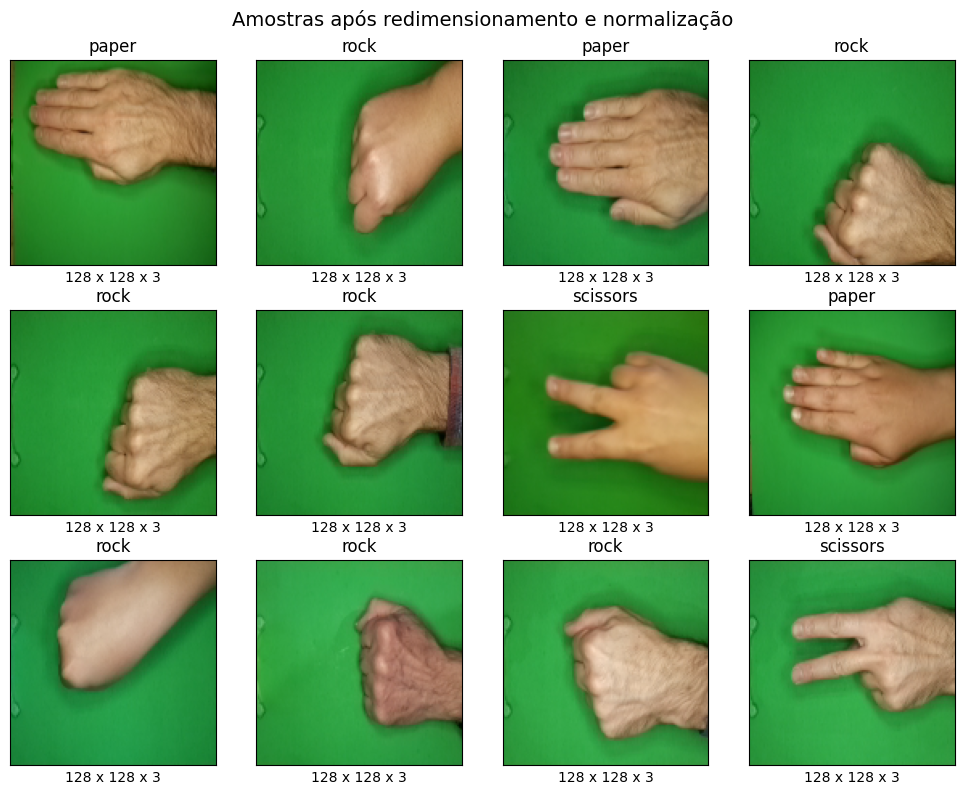

In [43]:
# --- Visualizando imagens após o pipeline de carregamento ---

plt.figure(figsize=(10, 8))

for imagens_batch, labels_batch in ds_treino_tuning.take(1):
    for i in range(12):
        altura = imagens_batch[i].shape[0]
        largura = imagens_batch[i].shape[1]
        canais = imagens_batch[i].shape[2]

        plt.subplot(3, 4, i + 1)
        plt.imshow(imagens_batch[i])
        plt.title(class_names[int(labels_batch[i])])
        plt.xlabel(f"{largura} x {altura} x {canais}")
        plt.xticks([])
        plt.yticks([])

plt.suptitle("Amostras após redimensionamento e normalização", fontsize=14)
plt.tight_layout()
plt.show()

# CNN baseline

In [44]:
# --- Função para criar uma CNN baseline ---

def criar_cnn_baseline():
    model = keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

    # --- Criando e visualizando a arquitetura baseline ---

modelo_baseline = criar_cnn_baseline()
modelo_baseline.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,707 (28.20 MB)

 Trainable params: 7,392,707 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Treinamento da CCN baseline

In [45]:
# --- Early stopping para evitar treinamento desnecessário ---

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# --- Treinamento da CNN baseline na amostra de tuning ---

EPOCHS_BASELINE = 15

history_baseline = modelo_baseline.fit(
    ds_treino_tuning,
    validation_data=ds_validacao_tuning,
    epochs=EPOCHS_BASELINE,
    callbacks=[early_stopping],
    verbose=1
)

# --- Função para plotar curvas de treino e validação ---

def plotar_curvas_treinamento(history, titulo="Curvas de treinamento"):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Treino")
    plt.plot(epochs_range, val_acc, label="Validação")
    plt.title("Acurácia")
    plt.xlabel("Época")
    plt.ylabel("Acurácia")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Treino")
    plt.plot(epochs_range, val_loss, label="Validação")
    plt.title("Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.7497 - loss: 0.6164 - val_accuracy: 0.9088 - val_loss: 0.3149
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9229 - loss: 0.2263 - val_accuracy: 0.9271 - val_loss: 0.2229
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9549 - loss: 0.1345 - val_accuracy: 0.9483 - val_loss: 0.1719
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9725 - loss: 0.0864 - val_accuracy: 0.9514 - val_loss: 0.1350
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9889 - loss: 0.0413 - val_accuracy: 0.9483 - val_loss: 0.1645
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.9856 - loss: 0.0382 - val_accuracy: 0.9605 - val_loss: 0.1239
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9941 - loss: 0.0281 - val_accuracy: 0.9666 - val_loss: 0.1226
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9948 - loss: 0.0170 - val_accuracy: 0.9574 - 

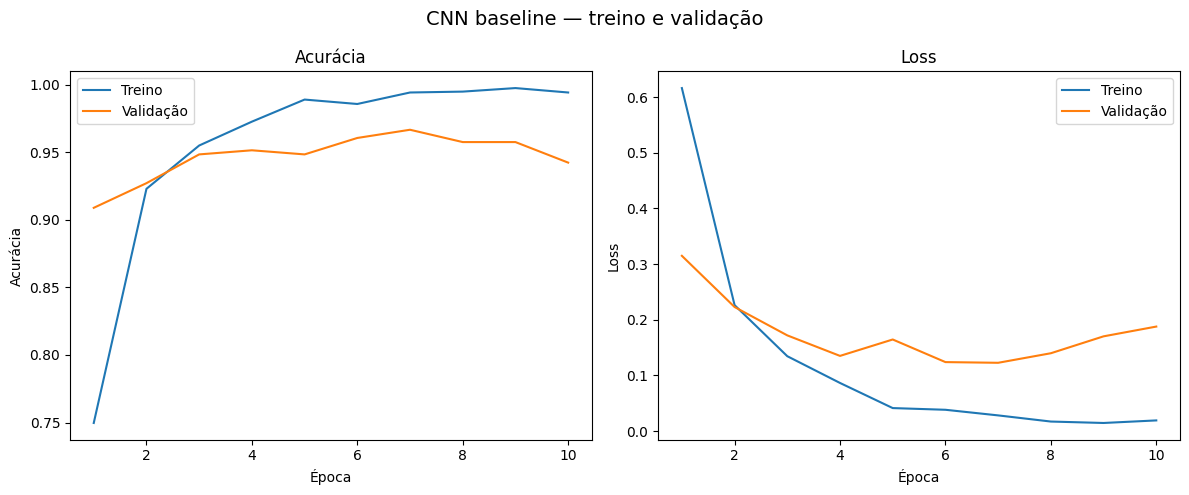

In [46]:
plotar_curvas_treinamento(history_baseline, "CNN baseline — treino e validação")

In [47]:
# --- Melhor desempenho da baseline na validação ---

melhor_val_acc_baseline = max(history_baseline.history["val_accuracy"])
melhor_val_loss_baseline = min(history_baseline.history["val_loss"])

print(f"📌 Melhor acurácia de validação da baseline: {melhor_val_acc_baseline:.4f}")
print(f"📌 Menor loss de validação da baseline: {melhor_val_loss_baseline:.4f}")

📌 Melhor acurácia de validação da baseline: 0.9666
📌 Menor loss de validação da baseline: 0.1226


# CNN para tuning

In [48]:
# --- Função para criar uma CNN com hiperparâmetros definidos pelo Optuna ---

def criar_cnn_optuna(trial):
    num_filtros_1 = trial.suggest_int("num_filtros_1", 16, 64, step=16)
    num_filtros_2 = trial.suggest_int("num_filtros_2", 32, 128, step=32)
    dense_units = trial.suggest_int("dense_units", 64, 256, step=64)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

    model = keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        keras.layers.Conv2D(num_filtros_1, (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(num_filtros_2, (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),
        keras.layers.Dense(dense_units, activation="relu"),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Configuração das trials (função objetivo)

In [49]:
# --- Função objetivo ---
# Cada trial corresponde a uma configuração diferente de hiperparâmetros.

def objective(trial):
    model = criar_cnn_optuna(trial)

    early_stopping_trial = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        ds_treino_tuning,
        validation_data=ds_validacao_tuning,
        epochs=10,
        callbacks=[early_stopping_trial],
        verbose=0
    )

    melhor_val_accuracy = max(history.history["val_accuracy"])

    return melhor_val_accuracy

In [50]:
# --- Execução do Optuna com TPE ---
# Orçamento fixo: número máximo de trials.

N_TRIALS = 15

sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

study.optimize(objective, n_trials=N_TRIALS)

[I 2026-06-08 22:21:48,535] A new study created in memory with name: no-name-867a88e3-d858-4d62-930a-87bab1f612c1
[I 2026-06-08 22:22:26,718] Trial 0 finished with value: 0.49240121245384216 and parameters: {'num_filtros_1': 32, 'num_filtros_2': 128, 'dense_units': 192, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0002051338263087451}. Best is trial 0 with value: 0.49240121245384216.
[I 2026-06-08 22:22:47,053] Trial 1 finished with value: 0.7507598996162415 and parameters: {'num_filtros_1': 16, 'num_filtros_2': 32, 'dense_units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.0026070247583707684}. Best is trial 1 with value: 0.7507598996162415.
[I 2026-06-08 22:23:08,102] Trial 2 finished with value: 0.33130699396133423 and parameters: {'num_filtros_1': 16, 'num_filtros_2': 128, 'dense_units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0002310201887845295}. Best is trial 1 with value: 0.7507598996162415.
[I 2026-06-08 22:23:26,608] Trial 3 finished with value: 0.38905775547

In [51]:
# --- Melhor configuração encontrada pelo Optuna ---

print(" Melhor trial:")
print(f"Número do trial: {study.best_trial.number}")
print(f"Acurácia de validação: {study.best_value:.4f}")

print("\n Hiperparâmetros encontrados:")
for param, value in study.best_params.items():
    print(f"{param}: {value}")

 Melhor trial:
Número do trial: 10
Acurácia de validação: 0.8754

 Hiperparâmetros encontrados:
num_filtros_1: 48
num_filtros_2: 96
dense_units: 128
dropout_rate: 0.1
learning_rate: 0.008985306233497345


In [52]:
# --- Tabela comparativa dos trials do Optuna ---

df_trials = study.trials_dataframe()

# Seleciona apenas as colunas mais relevantes para análise
colunas_interesse = [
    "number",
    "value",
    "params_num_filtros_1",
    "params_num_filtros_2",
    "params_dense_units",
    "params_dropout_rate",
    "params_learning_rate",
    "state"
]

df_trials_resumo = df_trials[colunas_interesse].copy()

# Renomeia colunas para facilitar leitura
df_trials_resumo = df_trials_resumo.rename(columns={
    "number": "trial",
    "value": "val_accuracy",
    "params_num_filtros_1": "filtros_1",
    "params_num_filtros_2": "filtros_2",
    "params_dense_units": "dense_units",
    "params_dropout_rate": "dropout",
    "params_learning_rate": "learning_rate",
    "state": "status"
})

# Ordena pelo melhor desempenho
df_trials_resumo = df_trials_resumo.sort_values(
    by="val_accuracy",
    ascending=False
).reset_index(drop=True)

display(df_trials_resumo)

,trial,val_accuracy,filtros_1,filtros_2,dense_units,dropout,learning_rate,status
0,10,0.875380,48,96,128,0.1,0.008985,COMPLETE
1,11,0.872340,48,96,128,0.1,0.009891,COMPLETE
2,13,0.826748,48,96,128,0.1,0.003764,COMPLETE
3,6,0.814590,48,32,64,0.5,0.008536,COMPLETE
4,8,0.784195,16,64,64,0.5,0.000329,COMPLETE
5,1,0.750760,16,32,256,0.4,0.002607,COMPLETE
6,4,0.626140,48,32,128,0.2,0.000817,COMPLETE
7,9,0.617021,48,64,192,0.3,0.000234,COMPLETE
8,7,0.592705,64,64,64,0.4,0.000759,COMPLETE
9,12,0.522796,32,96,128,0.1,0.009845,COMPLETE


In [53]:
# --- Gráfico de histórico da otimização ---
# Mostra como a melhor acurácia de validação evoluiu ao longo dos trials.

optuna.visualization.plot_optimization_history(study)

In [54]:
# --- Gráfico de importância dos hiperparâmetros ---
# Atenção: com poucos trials, este gráfico é apenas indicativo.

optuna.visualization.plot_param_importances(study)

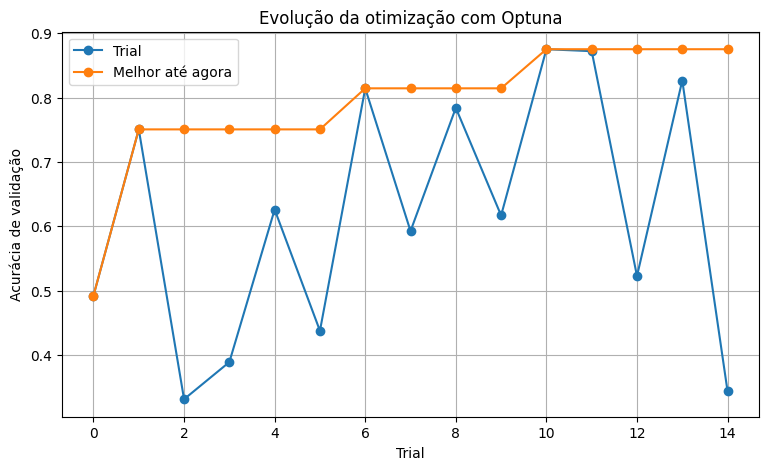

In [55]:
# --- Alternativa em Matplotlib: evolução dos trials ---

df_trials_plot = df_trials_resumo.sort_values("trial").copy()
df_trials_plot["melhor_ate_agora"] = df_trials_plot["val_accuracy"].cummax()

plt.figure(figsize=(9, 5))
plt.plot(df_trials_plot["trial"], df_trials_plot["val_accuracy"], marker="o", label="Trial")
plt.plot(df_trials_plot["trial"], df_trials_plot["melhor_ate_agora"], marker="o", label="Melhor até agora")

plt.xlabel("Trial")
plt.ylabel("Acurácia de validação")
plt.title("Evolução da otimização com Optuna")
plt.legend()
plt.grid(True)
plt.show()

# Treinamento com o dataset completo

In [56]:
# --- Criação do modelo vencedor com os melhores hiperparâmetros ---

best_params = study.best_params

def criar_cnn_com_params(params):
    model = keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        keras.layers.Conv2D(params["num_filtros_1"], (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(params["num_filtros_2"], (3, 3), activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),
        keras.layers.Dense(params["dense_units"], activation="relu"),
        keras.layers.Dropout(params["dropout_rate"]),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

modelo_vencedor = criar_cnn_com_params(best_params)
modelo_vencedor.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)              │ (None, 126, 126, 48)   │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 126, 126, 48)   │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 63, 63, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 61, 61, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 61, 61, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 30, 30, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_33 (Flatten)            │ (None, 86400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 128)            │    11,059,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,103,203 (42.36 MB)

 Trainable params: 11,102,915 (42.35 MB)

 Non-trainable params: 288 (1.12 KB)

In [57]:
# --- Datasets completos para treino final e avaliação ---

ds_treino = criar_dataset(df_treino, shuffle=True)
ds_validacao = criar_dataset(df_validacao, shuffle=False)
ds_teste = criar_dataset(df_teste, shuffle=False)

print(" Datasets completos criados.")

 Datasets completos criados.


Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.3817 - loss: 40.8033 - val_accuracy: 0.3343 - val_loss: 28.1766
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3464 - loss: 1.6197 - val_accuracy: 0.3374 - val_loss: 6.0203
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.3209 - loss: 1.4812 - val_accuracy: 0.3009 - val_loss: 2.5417


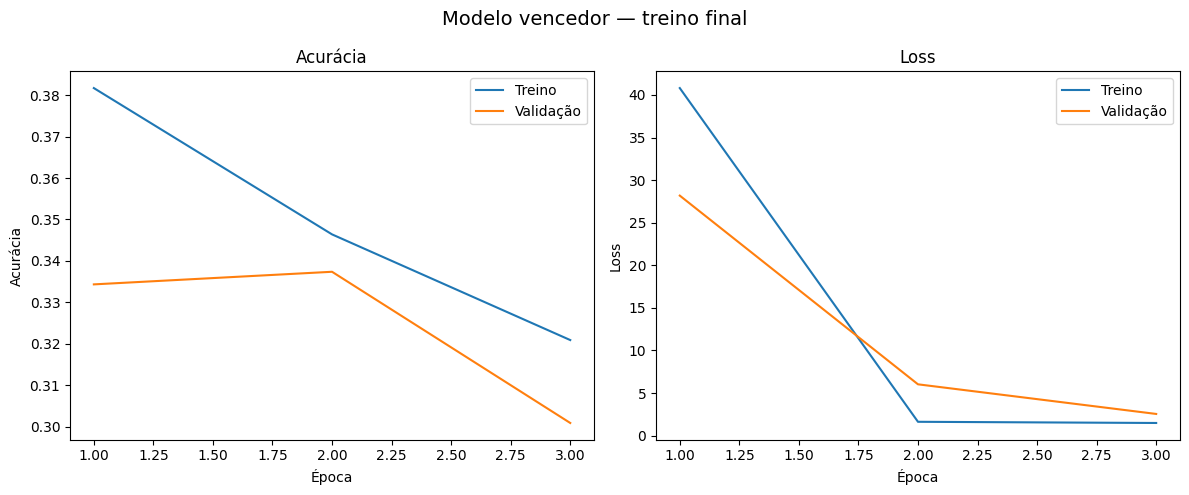

In [58]:
# --- Treinamento final do modelo vencedor com o conjunto de treino completo ---

EPOCHS_FINAL = 20

history_vencedor = modelo_vencedor.fit(
    ds_treino,
    validation_data=ds_validacao,
    epochs=EPOCHS_FINAL,
    callbacks=[early_stopping],
    verbose=1
)

plotar_curvas_treinamento(history_vencedor, "Modelo vencedor — treino final")

In [59]:
# --- Avaliação final no conjunto de teste ---

test_loss, test_acc = modelo_vencedor.evaluate(ds_teste, verbose=1)

print(f" Loss no teste: {test_loss:.4f}")
print(f" Acurácia no teste: {test_acc:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3404 - loss: 30.7123
 Loss no teste: 30.7123
 Acurácia no teste: 0.3404


In [60]:
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model_resnet.trainable = False

model_resnet = models.Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [61]:
history_resnet = model_resnet.fit(
    ds_treino,
    validation_data=ds_validacao,
    epochs=15,
    verbose=1
)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 271ms/step - accuracy: 0.3412 - loss: 1.1926 - val_accuracy: 0.3435 - val_loss: 1.0920
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.3601 - loss: 1.1233 - val_accuracy: 0.3435 - val_loss: 1.0882
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3693 - loss: 1.1088 - val_accuracy: 0.4255 - val_loss: 1.0855
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.3490 - loss: 1.1209 - val_accuracy: 0.3435 - val_loss: 1.0841
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3523 - loss: 1.1210 - val_accuracy: 0.3404 - val_loss: 1.0788
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.3549 - loss: 1.1106 - val_accuracy: 0.3313 - val_loss: 1.0802
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.3922 - loss: 1.0938 - val_accuracy: 0.8267 - val_loss: 1.0702
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4124 - loss: 1.0864 - val_accuracy: 0.5167 -

In [62]:
melhor_val_acc_resnet = max(history_resnet.history["val_accuracy"])
melhor_val_loss_resnet = min(history_resnet.history["val_loss"])

print(f"📌 Melhor acurácia de validação da ResNet: {melhor_val_acc_resnet:.4f}")
print(f"📌 Menor loss de validação da ResNet: {melhor_val_loss_resnet:.4f}")

📌 Melhor acurácia de validação da ResNet: 0.8267
📌 Menor loss de validação da ResNet: 1.0391


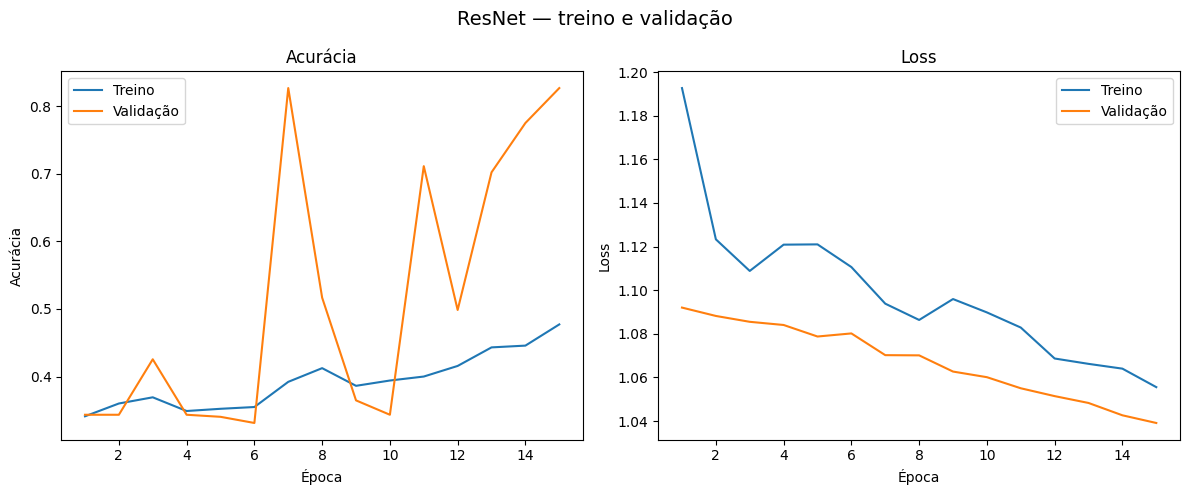

In [63]:
plotar_curvas_treinamento(history_resnet, "ResNet — treino e validação")

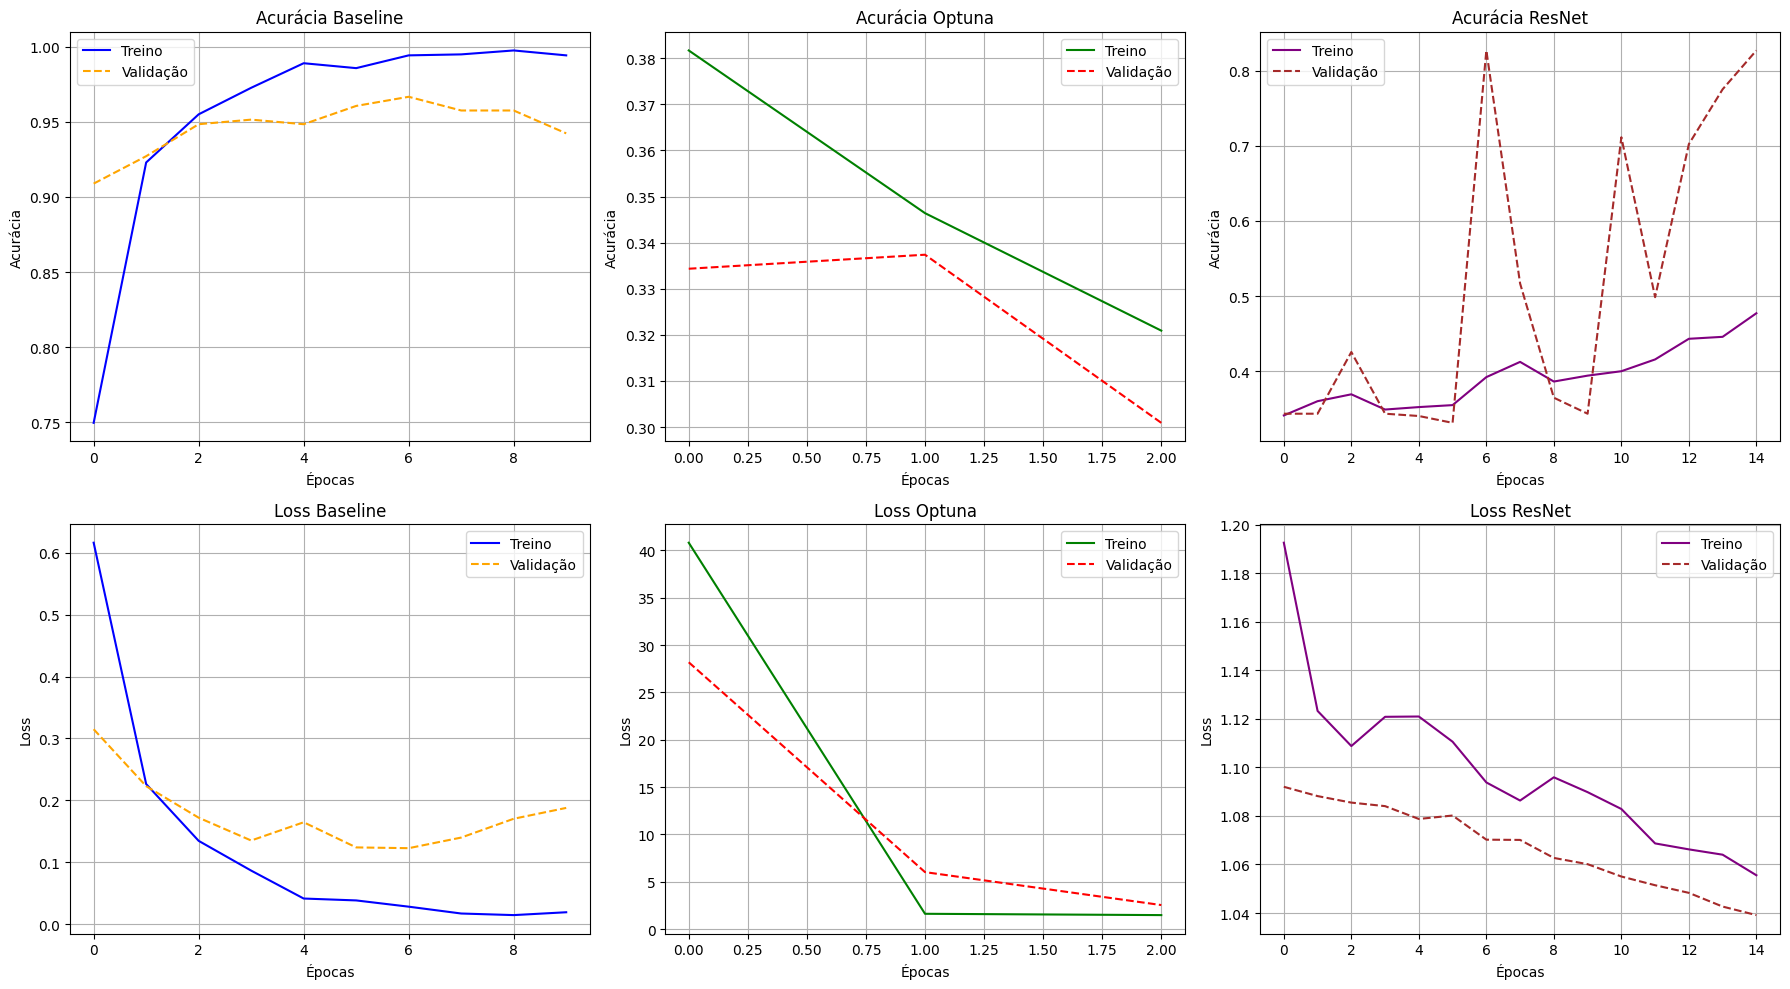

In [64]:
def comp_graficos(hist_baseline, hist_optuna, hist_resnet):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].plot(hist_baseline.history['accuracy'], label='Treino', color='blue')
    axes[0, 0].plot(hist_baseline.history['val_accuracy'], label='Validação', color='orange', linestyle='--')
    axes[0, 0].set_title('Acurácia Baseline')
    axes[0, 0].set_xlabel('Épocas')
    axes[0, 0].set_ylabel('Acurácia')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(hist_optuna.history['accuracy'], label='Treino', color='green')
    axes[0, 1].plot(hist_optuna.history['val_accuracy'], label='Validação', color='red', linestyle='--')
    axes[0, 1].set_title('Acurácia Optuna')
    axes[0, 1].set_xlabel('Épocas')
    axes[0, 1].set_ylabel('Acurácia')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[0, 2].plot(hist_resnet.history['accuracy'], label='Treino', color='purple')
    axes[0, 2].plot(hist_resnet.history['val_accuracy'], label='Validação', color='brown', linestyle='--')
    axes[0, 2].set_title('Acurácia ResNet')
    axes[0, 2].set_xlabel('Épocas')
    axes[0, 2].set_ylabel('Acurácia')
    axes[0, 2].legend()
    axes[0, 2].grid(True)

    axes[1, 0].plot(hist_baseline.history['loss'], label='Treino', color='blue')
    axes[1, 0].plot(hist_baseline.history['val_loss'], label='Validação', color='orange', linestyle='--')
    axes[1, 0].set_title('Loss Baseline')
    axes[1, 0].set_xlabel('Épocas')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(hist_optuna.history['loss'], label='Treino', color='green')
    axes[1, 1].plot(hist_optuna.history['val_loss'], label='Validação', color='red', linestyle='--')
    axes[1, 1].set_title('Loss Optuna')
    axes[1, 1].set_xlabel('Épocas')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    axes[1, 2].plot(hist_resnet.history['loss'], label='Treino', color='purple')
    axes[1, 2].plot(hist_resnet.history['val_loss'], label='Validação', color='brown', linestyle='--')
    axes[1, 2].set_title('Loss ResNet')
    axes[1, 2].set_xlabel('Épocas')
    axes[1, 2].set_ylabel('Loss')
    axes[1, 2].legend()
    axes[1, 2].grid(True)

    plt.tight_layout()
    plt.show()

comp_graficos(history_baseline, history_vencedor, history_resnet)

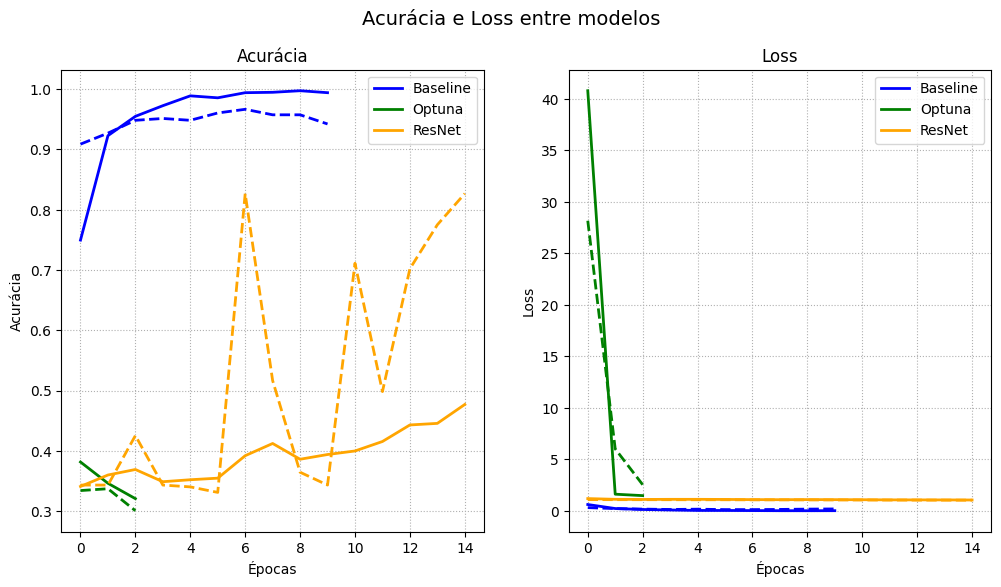

In [65]:
def comp_graficos_unico(hist_baseline, hist_optuna, hist_resnet):
  fig, axes = plt.subplots(1, 2, figsize=(12, 6))

  axes[0].plot(hist_baseline.history['accuracy'], label='Baseline', color='blue', linewidth=2)
  axes[0].plot(hist_baseline.history['val_accuracy'], color='blue', linewidth=2, linestyle='--')
  axes[0].plot(hist_optuna.history['accuracy'], label='Optuna', color='green', linewidth=2)
  axes[0].plot(hist_optuna.history['val_accuracy'], color='green', linewidth=2, linestyle='--')
  axes[0].plot(hist_resnet.history['accuracy'], label='ResNet', color='orange', linewidth=2)
  axes[0].plot(hist_resnet.history['val_accuracy'], color='orange', linewidth=2, linestyle='--')
  axes[0].set_title('Acurácia')
  axes[0].set_xlabel('Épocas')
  axes[0].set_ylabel('Acurácia')
  axes[0].legend(loc='upper right')
  axes[0].grid(True, linestyle=':')

  axes[1].plot(hist_baseline.history['loss'], label='Baseline', color='blue', linewidth=2)
  axes[1].plot(hist_baseline.history['val_loss'], color='blue', linewidth=2, linestyle='--')
  axes[1].plot(hist_optuna.history['loss'], label='Optuna', color='green', linewidth=2)
  axes[1].plot(hist_optuna.history['val_loss'], color='green', linewidth=2, linestyle='--')
  axes[1].plot(hist_resnet.history['loss'], label='ResNet', color='orange', linewidth=2)
  axes[1].plot(hist_resnet.history['val_loss'], color='orange', linewidth=2, linestyle='--')
  axes[1].set_title('Loss')
  axes[1].set_xlabel('Épocas')
  axes[1].set_ylabel('Loss')
  axes[1].legend(loc='upper right')
  axes[1].grid(True, linestyle=':')

  plt.suptitle("Acurácia e Loss entre modelos", fontsize=14)
  plt.show()

comp_graficos_unico(history_baseline, history_vencedor, history_resnet)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 469ms/step


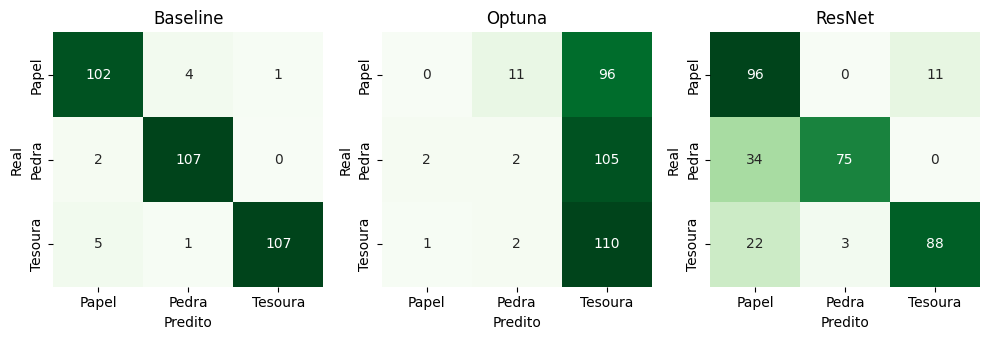

In [66]:
def matrizes_de_confusao(modelos, nomes):
  fig, axes = plt.subplots(1, len(modelos), figsize=(10, 3.5))
  for i in range(len(modelos)):
    modelo = modelos[i]
    nome = nomes[i]

    y_true = df_teste["label_id"].values
    y_pred_probs = modelo.predict(ds_teste)
    y_pred = np.argmax(y_pred_probs, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    nomes_das_classes = ['Papel', 'Pedra', 'Tesoura']

    sns.heatmap(
      cm,
      annot=True,
      fmt='d',
      cmap='Greens',
      xticklabels=nomes_das_classes,
      yticklabels=nomes_das_classes,
      ax=axes[i],
      cbar=False
    )

    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predito')
    axes[i].set_title(nome)
  plt.tight_layout()
  plt.show()

matrizes_de_confusao(
    [modelo_baseline, modelo_vencedor, model_resnet],
    ["Baseline", "Optuna", "ResNet"]
)

,Modelo,Acurácia de validação
0,CNN baseline,0.966565
1,CNN otimizada com Optuna,0.875380
2,CNN ResNet50,0.826748


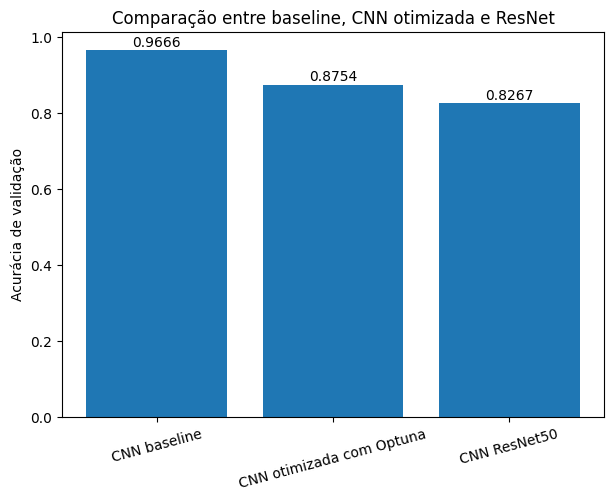

In [67]:
# --- Comparação entre baseline e melhor modelo encontrado pelo Optuna ---

df_comparacao_validacao = pd.DataFrame({
    "Modelo": ["CNN baseline", "CNN otimizada com Optuna", "CNN ResNet50"],
    "Acurácia de validação": [melhor_val_acc_baseline, study.best_value, melhor_val_acc_resnet]
})

display(df_comparacao_validacao)

# --- Gráfico comparativo: baseline vs Optuna ---

plt.figure(figsize=(7, 5))
plt.bar(
    df_comparacao_validacao["Modelo"],
    df_comparacao_validacao["Acurácia de validação"]
)

plt.ylabel("Acurácia de validação")
plt.title("Comparação entre baseline, CNN otimizada e ResNet")

for i, valor in enumerate(df_comparacao_validacao["Acurácia de validação"]):
    plt.text(i, valor + 0.01, f"{valor:.4f}", ha="center")

plt.xticks(rotation=15)
plt.show()

In [68]:
# --- Tabela final de comparação ---

df_resultado_final = pd.DataFrame({
    "Modelo/Etapa": [
        "CNN baseline - validação tuning",
        "Melhor Optuna - validação tuning",
        "ResNet - validação tuning",
        "Modelo do teste final"
    ],
    "Acurácia": [
        melhor_val_acc_baseline,
        study.best_value,
        melhor_val_acc_resnet,
        test_acc
    ]
})

display(df_resultado_final)

,Modelo/Etapa,Acurácia
0,CNN baseline - validação tuning,0.966565
1,Melhor Optuna - validação tuning,0.875380
2,ResNet - validação tuning,0.826748
3,Modelo do teste final,0.340426
